In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.17.1


In [ ]:
train_dir = Path('/content/drive/MyDrive/archive (1)/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

In [ ]:
test_dir = Path('/content/drive/MyDrive/archive (1)/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))


In [ ]:
val_dir = Path('/content/drive/MyDrive/archive (1)/validation')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [ ]:
def image_processing(filepath):
    labels = [str(filepath[i]).split("/")[-2] \
              for i in range(len(filepath))]

    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')

    df = pd.concat([filepath, labels], axis=1)

    df = df.sample(frac=1).reset_index(drop = True)

    return df

In [ ]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [ ]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 2780

Number of different labels: 36

Labels: ['potato' 'sweetcorn' 'watermelon' 'jalepeno' 'tomato' 'apple' 'pineapple'
 'paprika' 'soy beans' 'grapes' 'spinach' 'raddish' 'pomegranate' 'carrot'
 'capsicum' 'lettuce' 'mango' 'eggplant' 'kiwi' 'corn' 'beetroot' 'peas'
 'garlic' 'pear' 'cucumber' 'lemon' 'cauliflower' 'ginger' 'chilli pepper'
 'bell pepper' 'orange' 'turnip' 'cabbage' 'banana' 'onion' 'sweetpotato']


In [ ]:
train_df.head(5)

,Filepath,Label
0,/content/drive/MyDrive/archive (1)/train/potat...,potato
1,/content/drive/MyDrive/archive (1)/train/sweet...,sweetcorn
2,/content/drive/MyDrive/archive (1)/train/water...,watermelon
3,/content/drive/MyDrive/archive (1)/train/jalep...,jalepeno
4,/content/drive/MyDrive/archive (1)/train/tomat...,tomato


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('Filepath').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('index', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Filepath')):
  _plot_series(series, series_name, i)
  fig.legend(title='Filepath', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Label'].value_counts()
    for x_label, grp in _df_6.groupby('Filepath')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Filepath')
_ = plt.ylabel('Label')

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_7['Filepath'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_7, x='index', y='Filepath', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['Label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='index', y='Label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

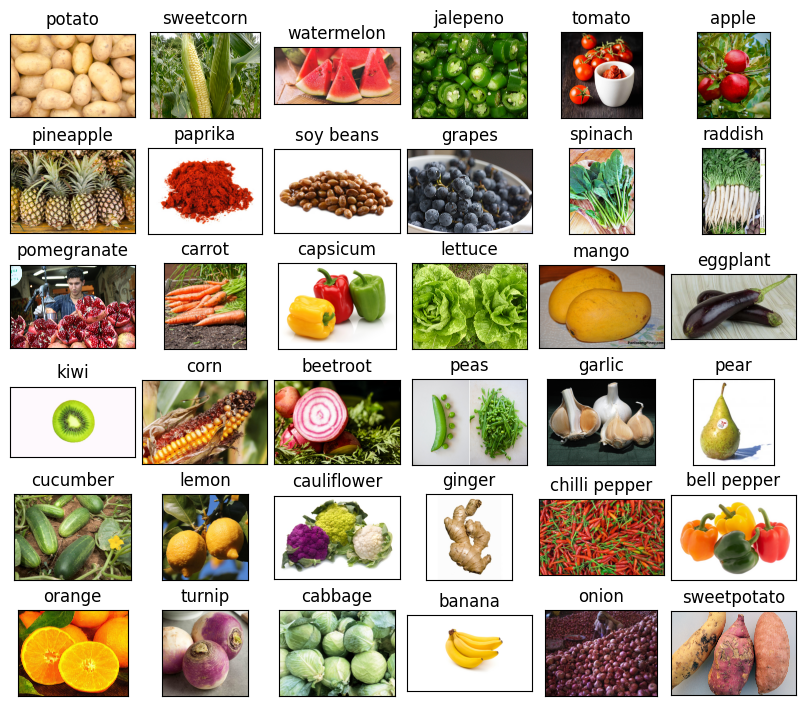

In [ ]:
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 2780 validated image filenames belonging to 36 classes.


In [ ]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 334 validated image filenames belonging to 36 classes.


In [ ]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 334 validated image filenames belonging to 36 classes.


In [ ]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(36, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 64,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


87/87 ━━━━━━━━━━━━━━━━━━━━ 1226s 13s/step - accuracy: 0.3597 - loss: 2.5514 - val_accuracy: 0.8683 - val_loss: 0.4781
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 86s 902ms/step - accuracy: 0.8097 - loss: 0.6282 - val_accuracy: 0.9012 - val_loss: 0.2983
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 83s 879ms/step - accuracy: 0.9014 - loss: 0.3267 - val_accuracy: 0.9341 - val_loss: 0.2508
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 83s 873ms/step - accuracy: 0.9294 - loss: 0.2260 - val_accuracy: 0.9641 - val_loss: 0.1958
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 85s 901ms/step - accuracy: 0.9481 - loss: 0.1574 - val_accuracy: 0.9611 - val_loss: 0.1555


In [ ]:
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


['raddish',
 'soy beans',
 'mango',
 'apple',
 'bell pepper',
 'pineapple',
 'paprika',
 'tomato',
 'cabbage',
 'chilli pepper',
 'soy beans',
 'cucumber',
 'beetroot',
 'pomegranate',
 'ginger',
 'cabbage',
 'grapes',
 'chilli pepper',
 'jalepeno',
 'lettuce',
 'kiwi',
 'pineapple',
 'paprika',
 'ginger',
 'mango',
 'peas',
 'chilli pepper',
 'cauliflower',
 'cauliflower',
 'potato',
 'eggplant',
 'pomegranate',
 'eggplant',
 'tomato',
 'spinach',
 'lemon',
 'beetroot',
 'orange',
 'kiwi',
 'corn',
 'paprika',
 'onion',
 'potato',
 'mango',
 'garlic',
 'pear',
 'potato',
 'onion',
 'turnip',
 'pomegranate',
 'paprika',
 'kiwi',
 'raddish',
 'tomato',
 'grapes',
 'soy beans',
 'onion',
 'kiwi',
 'tomato',
 'corn',
 'tomato',
 'watermelon',
 'apple',
 'lemon',
 'orange',
 'chilli pepper',
 'pineapple',
 'carrot',
 'corn',
 'pear',
 'turnip',
 'raddish',
 'cabbage',
 'pear',
 'orange',
 'grapes',
 'sweetcorn',
 'paprika',
 'corn',
 'watermelon',
 'ginger',
 'cucumber',
 'cucumber',
 'tom

In [ ]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


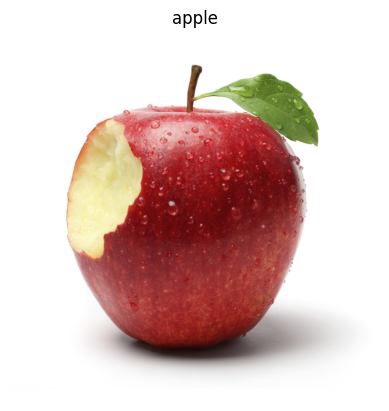

In [ ]:
img_path = '/content/drive/MyDrive/archive (1)/test/apple/Image_1.jpg'
img = output(img_path)
plt.imshow(plt.imread(img_path))
plt.axis('off')
plt.title(img)
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/cnnmodel/FV.h5')

In [ ]:
from keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model_path = '/content/drive/MyDrive/cnnmodel/FV.h5'
best_model = load_model(model_path)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

validation_dir = '/content/drive/MyDrive/archive (1)/validation'
batch_size = 32

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),  # Ensure this matches the input size of your model
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Important: Shuffle should be False for correct alignment of predictions with labels
)

Found 351 images belonging to 36 classes.


In [ ]:
classes = list(validation_generator.class_indices.keys())


Found 351 images belonging to 36 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 117s 11s/step
Classification Report:
               precision    recall  f1-score   support

        apple       1.00      0.50      0.67        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.75      1.00      0.86         9
      cabbage       1.00      1.00      1.00        10
     capsicum       1.00      0.60      0.75        10
       carrot       1.00      1.00      1.00         9
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.90      1.00      0.95         9
         corn       0.77      1.00      0.87        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       0.71      1.00      0.83        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      1.00      1.00         9
     jalepeno       1.00      1.00      1.00         9


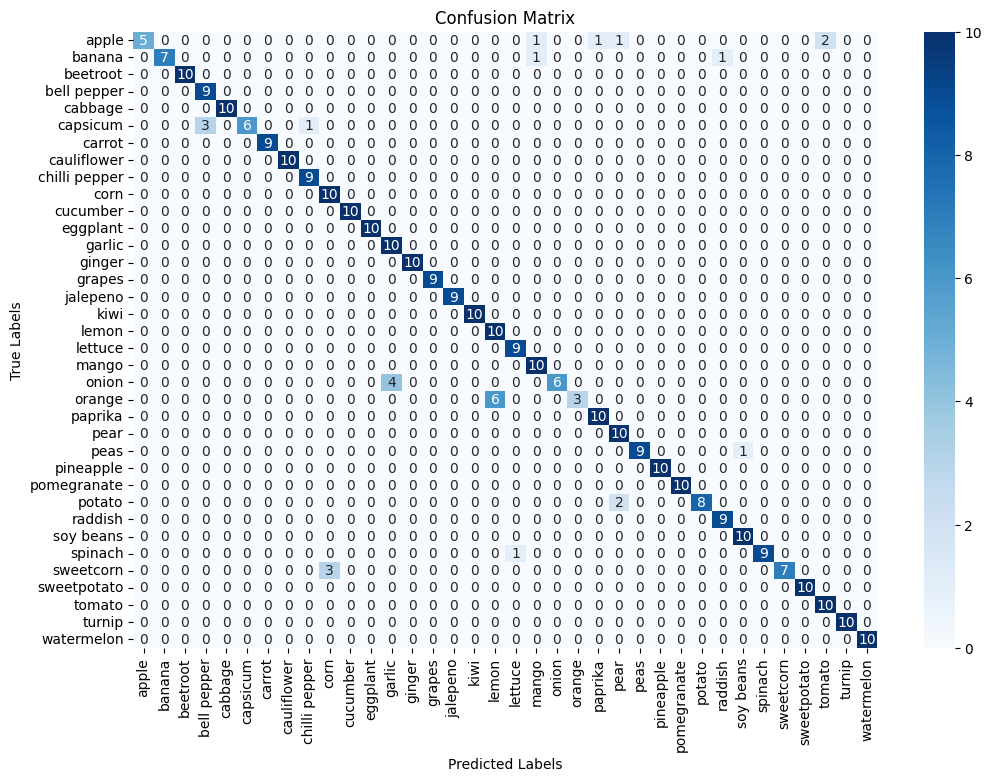

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def evaluate_model_performance(model, val_generator, class_labels):
    """
    Evaluate the model's performance on the validation set and print the classification report.

    Parameters:
    - model: The trained model.
    - val_generator: Validation data generator.
    - class_labels: List of class names.
    """
    # Get true labels
    true_labels = val_generator.classes

    # Get the predicted probabilities from the model
    predictions = model.predict(val_generator, steps=len(val_generator))

    # Convert predicted probabilities to class indices
    predicted_labels = np.argmax(predictions, axis=1)

    # Classification report
    report = classification_report(true_labels, predicted_labels, target_names=class_labels)
    print("Classification Report:")
    print(report)

    # Confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

# Load the trained model
model_path = '/content/drive/MyDrive/cnnmodel/FV.h5'
model = load_model(model_path)

# Prepare the validation data generator
validation_dir = '/content/drive/MyDrive/archive (1)/validation' # Replace with your validation dataset path
batch_size = 32
target_size = (224, 224)  # Ensure this matches the input size of your model

val_datagen = ImageDataGenerator(rescale=1.0 / 255)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is False to ensure correct alignment of labels
)

# Extract class labels
class_labels = list(validation_generator.class_indices.keys())

# Evaluate the model
evaluate_model_performance(model, validation_generator, class_labels)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model

# Load the trained model
model_path = '/content/drive/MyDrive/cnnmodel/FV.h5'  # Path to the saved model
model = load_model(model_path)

# Prepare the test data generator
test_dir = '/content/drive/MyDrive/archive (1)/train'  # Replace with the actual path to your test dataset
batch_size = 32
target_size = (224, 224)  # Ensure this matches the input size of your model

test_datagen = ImageDataGenerator(rescale=1.0 / 255)  # Normalizing pixel values
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Ensure labels align with data
)

# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator, steps=len(test_generator), verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4%}")


Found 3115 images belonging to 36 classes.


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


98/98 ━━━━━━━━━━━━━━━━━━━━ 920s 9s/step - accuracy: 0.8944 - loss: 0.3346
Test Loss: 0.3204
Test Accuracy: 89.7913%


In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.1 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import gradio as gr
from PIL import Image
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
from keras.models import load_model
import requests
from bs4 import BeautifulSoup

model = load_model('/content/drive/MyDrive/cnnmodel/FV.h5')
labels = {0: 'apple', 1: 'banana', 2: 'beetroot', 3: 'bell pepper', 4: 'cabbage', 5: 'capsicum', 6: 'carrot',
          7: 'cauliflower', 8: 'chilli pepper', 9: 'corn', 10: 'cucumber', 11: 'eggplant', 12: 'garlic', 13: 'ginger',
          14: 'grapes', 15: 'jalepeno', 16: 'kiwi', 17: 'lemon', 18: 'lettuce',
          19: 'mango', 20: 'onion', 21: 'orange', 22: 'paprika', 23: 'pear', 24: 'peas', 25: 'pineapple',
          26: 'pomegranate', 27: 'potato', 28: 'raddish', 29: 'soy beans', 30: 'spinach', 31: 'sweetcorn',
          32: 'sweetpotato', 33: 'tomato', 34: 'turnip', 35: 'watermelon'}

fruits = ['Apple', 'Banana', 'Bello Pepper', 'Chilli Pepper', 'Grapes', 'Jalepeno', 'Kiwi', 'Lemon', 'Mango', 'Orange',
          'Paprika', 'Pear', 'Pineapple', 'Pomegranate', 'Watermelon']
vegetables = ['Beetroot', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Corn', 'Cucumber', 'Eggplant', 'Ginger',
              'Lettuce', 'Onion', 'Peas', 'Potato', 'Raddish', 'Soy Beans', 'Spinach', 'Sweetcorn', 'Sweetpotato',
              'Tomato', 'Turnip']

def fetch_calories(prediction):
    try:
        url = 'https://www.google.com/search?&q=calories in ' + prediction
        print(url)
        req = requests.get(url).text
        scrap = BeautifulSoup(req, 'html.parser')
        print(scrap)
        calories = scrap.find("div", class_="BNeawe iBp4i AP7Wnd").text
        return calories
    except Exception as e:
        return "Error: Unable to fetch calorie information."

def processed_img(img):
    img = img.resize((224, 224))
    img = img_to_array(img)
    img = img / 255
    img = np.expand_dims(img, [0])
    answer = model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = int(y_class)
    res = labels[y]
    return res.capitalize()

def classify_image(image):
    result = processed_img(image)
    category = "Vegetable" if result in vegetables else "Fruit"
    cal_info = fetch_calories(result)
    return category, result, cal_info

def main():
    interface = gr.Interface(
        fn=classify_image,
        inputs=gr.Image(type="pil", label="Upload an Image"),
        outputs=[
            gr.Textbox(label="Category"),
            gr.Textbox(label="Predicted"),
            gr.Textbox(label="Calories (100g)")
        ],
        title="FOOD RECOGNATION AND CALORIE ESTIMATION",
        description="Upload an image of a Food Item to classify and get its calorie information."
    )
    interface.launch()

if __name__ == "__main__":
    main()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://861a36df246557c3b9.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
